In [ ]:
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt
import seaborn as sns

gdb_path = r'/work/pi_casey_umass_edu/Owen/Reservoirs/LakeSPvC_ts_for_Ted/SWOT_PLD_v106_reservoirs.gdb'

# List all layers in the geodatabase
layers = fiona.listlayers(gdb_path)


for layer in layers:
    globals()[layer] = gpd.read_file(gdb_path, layer=layer)
    print(f"Loaded layer: {layer}")
    display(globals()[layer].head())
    print(f"Shape: {globals()[layer].shape}")




/work/pi_casey_umass_edu/Owen/graph_delineator/.venv/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


Loaded layer: SWOT_PLD_v106_reservoirs


,lake_id,basin_id,names,res_id,reach_id_list,lon,lat,poly_area,poly_perimeter,ref_area,...,min_dist_river_id,sources,GeoDAR2b_f,area_geodesic_km2,GDW_flag,GeoDARv1_flag,lake_type,Shape_Length,Shape_Area,geometry
0,1.110000e+09,111,,NaN,,38.844163,15.435186,0.01260001267258544,0.8399999382443047,0.0126,...,1.722760e+10,Circa2015,1.0,0.012610,NaN,1.0,Reservoir,0.007712,0.000001,"MULTIPOLYGON (((38.84308 15.43608, 38.84364 15..."
1,1.110000e+09,111,,4479.0,,38.787424,15.257033,0.03599999162463006,1.139999729477843,0.0360,...,1.722760e+10,Circa2015,1.0,0.036028,1.0,1.0,Reservoir,0.010454,0.000003,"MULTIPOLYGON (((38.78706 15.25593, 38.78678 15..."
2,1.110000e+09,111,,4479.0,,38.797799,15.259410,0.5274000107255997,8.699999770653339,0.5274,...,1.722760e+10,Circa2015,1.0,0.527816,1.0,1.0,Reservoir,0.080044,0.000044,"MULTIPOLYGON (((38.79209 15.25513, 38.79097 15..."
3,1.110000e+09,111,,NaN,,38.838286,15.440852,0.1043999772089515,4.140000223181024,0.1044,...,1.722760e+10,Circa2015,1.0,0.104483,NaN,1.0,Reservoir,0.037950,0.000009,"MULTIPOLYGON (((38.83833 15.43716, 38.83693 15..."
4,1.110001e+09,111,HIMBIRTI WATER RESERVOIR,NaN,,38.726838,15.258002,0.05219999980651308,1.320000388858859,0.0522,...,1.722760e+10,Circa2015,1.0,0.052241,NaN,NaN,Reservoir,0.012097,0.000004,"MULTIPOLYGON (((38.72616 15.25641, 38.72588 15..."


In [20]:
print(SWOT_PLD_v106_reservoirs['lake_id'].dtype)

float64


Total entries below 500: 163724
Total entries above 500: 134
Mean Reservoir area: 3.469203223015699


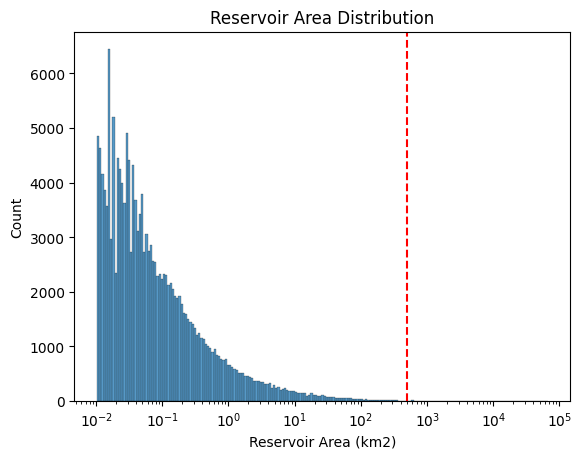

In [ ]:
#Plot Reservoir distribution
sns.histplot(data=SWOT_PLD_v106_reservoirs, x='area_geodesic_km2', log_scale=True)

plt.axvline(500, color='red', linestyle='--')
plt.xlabel('Reservoir Area (km2)')

below_500 = (SWOT_PLD_v106_reservoirs['area_geodesic_km2'] < 500).sum()
above_500 = (SWOT_PLD_v106_reservoirs['area_geodesic_km2'] >= 500).sum()
print(f"Total entries below 500: {below_500}")
print(f"Total entries above 500: {above_500}")

mean_area = SWOT_PLD_v106_reservoirs['area_geodesic_km2'].mean()
print(f"Mean Reservoir area: {mean_area}")

plt.title('Reservoir Area Distribution')
plt.show()